# Cross-Validation: Prioritization of Early Churn Detection & Retention Strategies

**Objective:** Build and compare models to predict Churn characteristics.

**Dataset:** `kkbox_dataset_testing`
  
**Target Variable:** Churn 

**Models Evaluated:** Logistic Regression, Random Forest, XGBoost

# 1.Setup and Data Loading

In [17]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("kkbox_dataset_training.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (970960, 51)
                                           msno  target  transaction_count  \
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=       1                6.0   
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=       1                5.0   
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=       1               18.0   
3  8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=       1               18.0   
4  K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=       1               24.0   

   avg_payment_method  avg_plan_days  total_plan_list_price  \
0           32.166667        30.0000                  298.0   
1           37.000000        25.4000                  627.0   
2           38.000000        30.0000                 2682.0   
3           40.666667        28.5625                 2235.0   
4           41.000000        30.0000                 2529.0   

   total_actual_paid  avg_actual_paid  discount_frequency  renewal_rate  ...  \
0              894.0       149.000000               

# 2. Basic Checks

In [3]:
print(df.columns.tolist())
print(df["target"].value_counts(dropna=False))
print(df["target"].value_counts(normalize=True, dropna=False))

['msno', 'target', 'transaction_count', 'avg_payment_method', 'avg_plan_days', 'total_plan_list_price', 'total_actual_paid', 'avg_actual_paid', 'discount_frequency', 'renewal_rate', 'cancel_count', 'avg_days_to_expire', 'max_days_to_expire', 'first_transaction_x', 'last_transaction_x', 'last_expire_x', 'total_subscription_length', 'plan_category', 'total_discount', 'max_discount', 'avg_discount_pct', 'discount_bucket', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time_x', 'account_age_days_x', 'Loyalty_Status', 'Age_Group', 'City_Tier', 'total_listening_time', 'avg_daily_usage', 'total_unique_songs', 'total_sessions', 'num_log_days', 'last_log_date_x', 'num_25_sum', 'num_100_sum', 'completion_rate', 'skip_rate', 'first_transaction_y', 'last_transaction_y', 'last_expire_y', 'registration_init_time_y', 'last_log_date_y', 'membership_duration', 'days_since_last_transaction', 'time_until_expiration', 'account_age_days_y', 'days_since_last_log']
target
0    883630
1     8733

# 3. Define features and target

In [4]:
X = df.drop(columns=["target", "msno"], errors="ignore").copy()
y = df["target"].copy()

print("Initial X shape:", X.shape)
print("Initial y shape:", y.shape)

Initial X shape: (970960, 49)
Initial y shape: (970960,)


# 4. Handle missing values

In [5]:
print("Missing values before fill:", X.isnull().sum().sum())
print(X.isnull().sum().sort_values(ascending=False).head(20))

df.fillna(df.median(numeric_only=True), inplace=True)

for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna("Unknown")

print("Missing values after fill:", X.isnull().sum().sum())

Missing values before fill: 5761029
discount_bucket             932476
bd                          584359
Age_Group                   584359
days_since_last_log         218330
last_log_date_y             218330
total_unique_songs          216409
total_sessions              216409
num_log_days                216409
num_100_sum                 216409
completion_rate             216409
total_listening_time        216409
avg_daily_usage             216409
last_log_date_x             216409
num_25_sum                  216409
skip_rate                   216409
account_age_days_y          112025
registration_init_time_y    112025
Loyalty_Status              111900
registered_via              109993
account_age_days_x          109993
dtype: int64
Missing values after fill: 0


# 5. Encode categorical/ Numerical variables

In [6]:
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# 6. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_sample = X_train.sample(100000, random_state=42)
y_sample = y_train.loc[X_sample.index]

print("X_train Sample:", X_sample.shape)
print("X_test Sample:", X_sample.shape)


X_train: (776768, 49)
X_test: (194192, 49)
X_train Sample: (100000, 49)
X_test Sample: (100000, 49)


# 7.Model Comparison 

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=1
    ),
    
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=1,
        tree_method="hist"
    )
}

param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [10, 20, 30, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.7, 0.8, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 1.0]
    }
}

# 8.Evaluate Model

In [10]:
cv_results = {}
best_models = {}

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "f1": "f1"
}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grids[name],
        n_iter=5,
        scoring=scoring,
        refit="roc_auc",   
        cv=3,
        n_jobs=1,
        random_state=42,
        verbose=1
    )

    search.fit(X_sample, y_sample)

    best_models[name] = search.best_estimator_

    best_idx = search.best_index_

    cv_results[name] = {
        "ROC-AUC Mean": search.cv_results_["mean_test_roc_auc"][best_idx],
        "ROC-AUC Std": search.cv_results_["std_test_roc_auc"][best_idx],
        "Accuracy Mean": search.cv_results_["mean_test_accuracy"][best_idx],
        "Accuracy Std": search.cv_results_["std_test_accuracy"][best_idx],
        "F1 Mean": search.cv_results_["mean_test_f1"][best_idx],
        "F1 Std": search.cv_results_["std_test_f1"][best_idx],
        "Best Params": search.best_params_
    }

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df

Fitting 3 folds for each of 5 candidates, totalling 15 fits


c:\Users\ADMIN 0\Downloads\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ADMIN 0\Downloads\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ADMIN 0\Downloads\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this w

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Fitting 3 folds for each of 5 candidates, totalling 15 fits


,ROC-AUC Mean,ROC-AUC Std,Accuracy Mean,Accuracy Std,F1 Mean,F1 Std,Best Params
Logistic Regression,0.905,0.002534,0.85909,0.001962,0.498039,0.003986,"{'model__solver': 'lbfgs', 'model__penalty': '..."
Random Forest,0.915421,0.002862,0.91769,0.0025,0.596707,0.010104,"{'model__n_estimators': 300, 'model__min_sampl..."
XGBoost,0.937276,0.001673,0.95155,0.00075,0.683833,0.008556,"{'model__subsample': 0.8, 'model__n_estimators..."


## 9. Final Model Fit + Test Set Evaluation**

In [21]:
# Pick the best model based on CV RMSE
best_model_name = cv_results_df["ROC-AUC Mean"].idxmax()
best_model = best_models[best_model_name]



y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_prob)

print("Best model from tuning:", best_model_name)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"Test ROC-AUC:  {test_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Best model from tuning: XGBoost
Test Accuracy: 0.9523
Test F1 Score: 0.6899
Test ROC-AUC:  0.9381

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97    176726
           1       0.83      0.59      0.69     17466

    accuracy                           0.95    194192
   macro avg       0.90      0.79      0.83    194192
weighted avg       0.95      0.95      0.95    194192


Confusion Matrix:
[[174611   2115]
 [  7154  10312]]


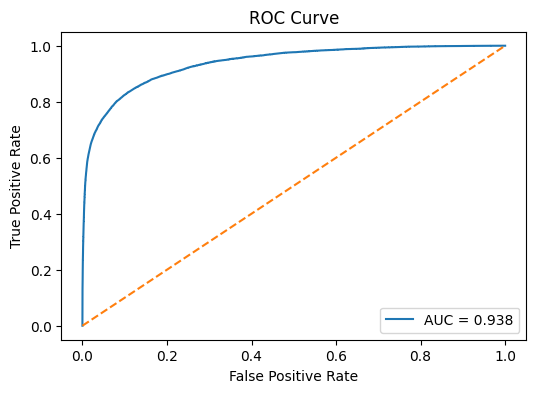

In [18]:
y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

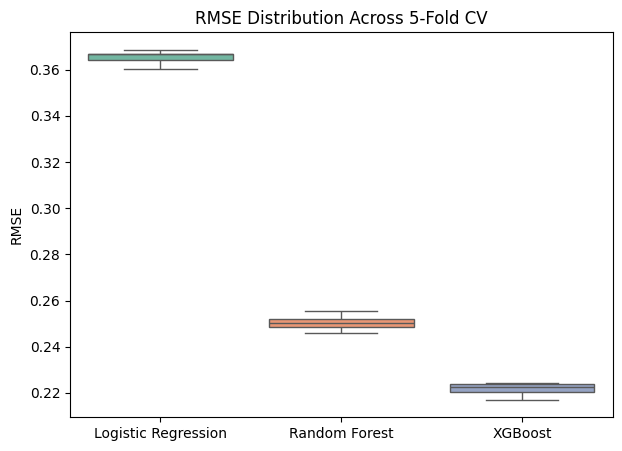

In [24]:
plt.figure(figsize=(7,5))

sns.boxplot(data=[-cross_val_score(
                    Pipeline([("preprocess", preprocess),
                              ("model", models[m])]),
                    X_sample, y_sample,
                    scoring="neg_root_mean_squared_error",
                    cv=cv)
                 for m in models],
            palette="Set2")

plt.xticks(ticks=range(len(models)), labels=list(models.keys()))
plt.title("RMSE Distribution Across 5-Fold CV")
plt.ylabel("RMSE")
plt.show()

## 10. Feature importances

In [25]:
model = best_models["XGBoost"]  

# Get one-hot encoder from the fitted preprocessor
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

# Combine numeric + encoded categorical feature names
features = np.concatenate([numeric_features, encoded_cat_features])

# Get feature importances from the Decision Tree
importances = model.named_steps["model"].feature_importances_

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
})

In [26]:
top10 = feat_imp.sort_values("importance", ascending=False).head(10)
print(top10)

                             feature  importance
29       days_since_last_transaction    0.051869
823      first_transaction_x_Unknown    0.047281
12051     last_log_date_y_2017-03-31    0.039404
7                       renewal_rate    0.038987
12052        last_log_date_y_Unknown    0.026797
12050     last_log_date_y_2017-03-30    0.024945
8                       cancel_count    0.016604
6071         last_log_date_x_Unknown    0.013889
1215   last_transaction_x_2017-02-11    0.013841
32               days_since_last_log    0.013004


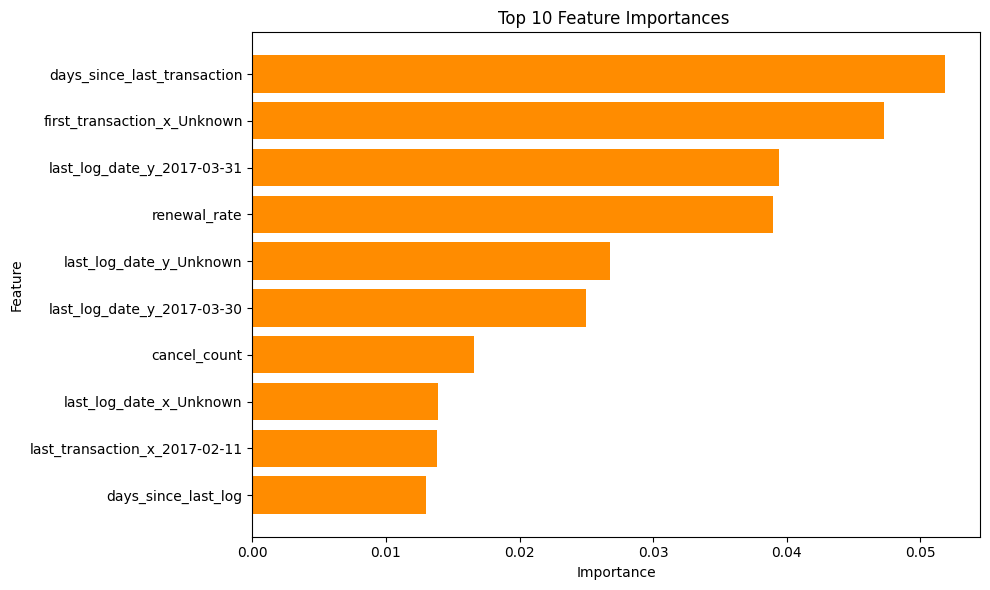

In [29]:
plt.figure(figsize=(10, 6))
plt.barh(top10["feature"], top10["importance"], color="darkorange")
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances ")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## **Insight Summary**
The XGBoost model demonstrates strong overall performance, achieving a high ROC-AUC of 0.938, which indicates excellent ability to distinguish between classes. While the model attains a high accuracy of 95.23%, this is largely influenced by class imbalance, as the majority class dominates the dataset. A more meaningful evaluation comes from the F1 score of 0.6899 for the minority class, reflecting a moderate balance between precision (0.83) and recall (0.59). The relatively lower recall shows that the model misses about 41% of actual positive cases, suggesting an opportunity for improvement, especially if detecting these cases is critical. The confusion matrix further confirms that the model is conservative, producing few false positives but a higher number of false negatives. Feature importance analysis reveals that recent user behavior—such as days since last transaction, last log activity, renewal rate, and cancellation count—plays the most significant role in predictions, highlighting the importance of temporal engagement patterns over static attributes. Overall, XGBoost outperforms the other models tested, but adjusting the decision threshold could improve recall and better align the model with the project’s objective.